In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_curve, auc
)
from imblearn.over_sampling import SMOTE
import joblib

In [2]:
data = pd.read_csv("creditcard.csv")

In [3]:
data = data.dropna(subset=["Class"])

X = data.drop("Class", axis=1)
y = data["Class"]

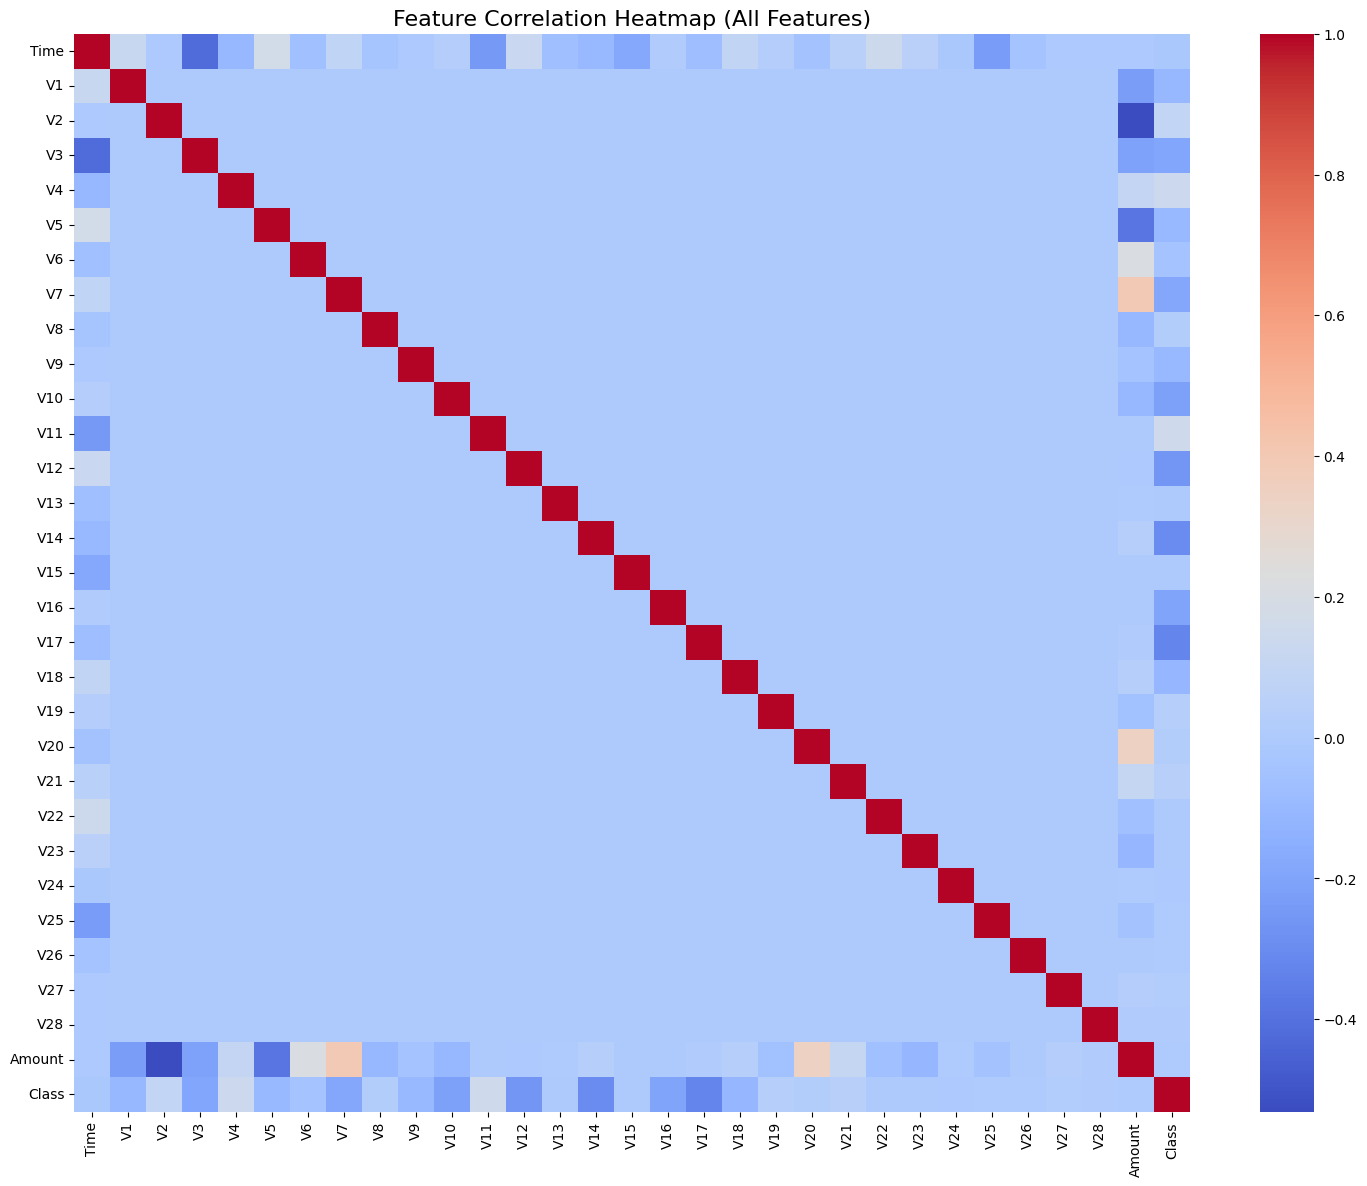

In [4]:
plt.figure(figsize=(18, 14))
corr = data.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap (All Features)", fontsize=16)
plt.show()

C:\Users\thath\AppData\Local\Temp\ipykernel_3920\2061107407.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_before.index, y=count_before.values, palette="coolwarm")


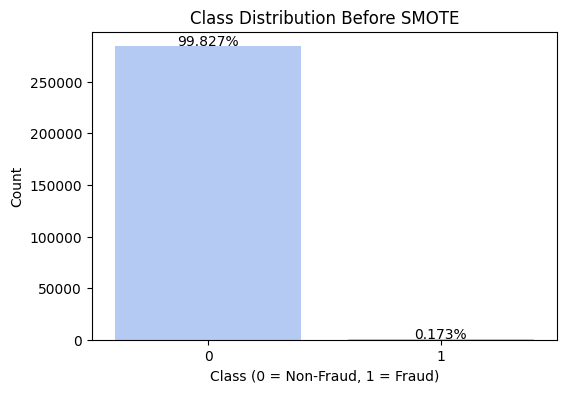

Class distribution before SMOTE:
 Class
0    284315
1       492
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(6, 4))
count_before = y.value_counts()
sns.barplot(x=count_before.index, y=count_before.values, palette="coolwarm")
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")

for i, val in enumerate(count_before.values):
    plt.text(i, val + 500, f"{(val / len(y))*100:.3f}%", ha='center', fontsize=10)
plt.show()

print("Class distribution before SMOTE:\n", count_before)

C:\Users\thath\AppData\Local\Temp\ipykernel_3920\4076369019.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_after.index, y=count_after.values, palette="viridis")


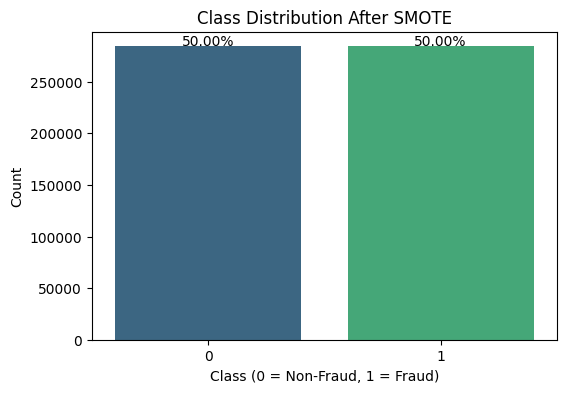


Class distribution after SMOTE:
 Class
0    284315
1    284315
Name: count, dtype: int64


In [6]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

plt.figure(figsize=(6, 4))
count_after = y_resampled.value_counts()
sns.barplot(x=count_after.index, y=count_after.values, palette="viridis")
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")

for i, val in enumerate(count_after.values):
    plt.text(i, val + 500, f"{(val / len(y_resampled))*100:.2f}%", ha='center', fontsize=10)
plt.show()

print("\nClass distribution after SMOTE:\n", count_after)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled
)


In [8]:
rf_model = RandomForestClassifier(
    n_estimators=60,        
    max_depth=8,            
    min_samples_split=3,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, min_samples_split=3, n_estimators=60,
                       n_jobs=-1, random_state=42)

In [9]:
y_pred = rf_model.predict(X_test)
acc=accuracy_score(y_test,y_pred)

print("\n Random Forest Model Results:")
print("Accuracy:", round(acc*100,2),'%')
print("\nClassification Report:\n", classification_report(y_test, y_pred))


 Random Forest Model Results:
Accuracy: 98.37 %

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     85295
           1       1.00      0.97      0.98     85294

    accuracy                           0.98    170589
   macro avg       0.98      0.98      0.98    170589
weighted avg       0.98      0.98      0.98    170589



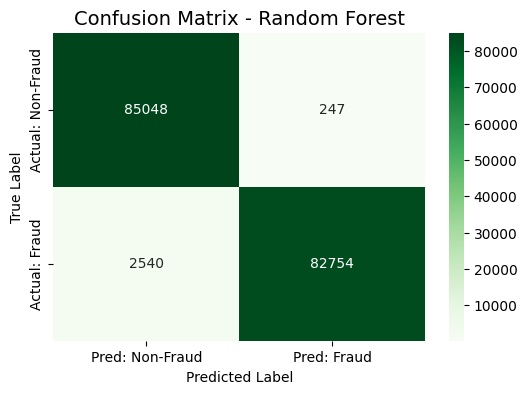

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Pred: Non-Fraud", "Pred: Fraud"],
    yticklabels=["Actual: Non-Fraud", "Actual: Fraud"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest", fontsize=14)
plt.show()

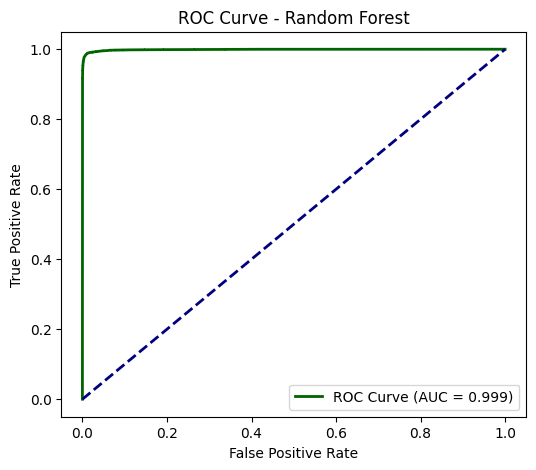

In [11]:
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkgreen', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.show()

In [12]:
joblib.dump(rf_model, "random_forest_model.pkl")
print("\nModel saved as random_forest_model.pkl")


Model saved as random_forest_model.pkl
